<a href="https://colab.research.google.com/github/DARRIVER900/AdminCanciones/blob/master/REGRESION_LINEAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REGRESION LINEAl:
Metodo matematico estadistico que estable la relacion entre la variable dependiente y demas variables mediante una linea recta. Es funcional en prediccion de ML

Seleccionar algoritmo:
Regresión lineal

* Predecir el precio de una casa con base al numero de habitaciones

Matematica:

La ecuación de una línea recta tiene la siguiente forma:

Y = β₀ + β₁X + ε,

donde:

Y es la variable independiente(lo que queremos encontrar).
β₀(intercepto en y) y β₁(pendiente) son dos constantes desconocidas que representan el punto de intersección y la pendiente respectivamente.
ε (epsilon) es la función de pérdida o error de predicion y valor real.

Objetivo: minizar el error total entre prediccion y valor real

In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/REGRESION_LINEAL/boston_house_prices.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


Estructura de los datos:

CRIM: tasa de criminalidad per cápita por ciudad.

ZN: proporción de suelo residencial destinado a parcelas de más de 25 000 pies cuadrados.

INDUS: proporción de acres destinados a negocios no minoristas por ciudad.

CHAS: variable ficticia del río Charles (1 si la zona limita con el río; 0 en caso contrario).

NOX: concentración de óxidos nítricos (partes por 10 millones).

RM: número medio de habitaciones por vivienda.

AGE: proporción de viviendas ocupadas por sus propietarios construidas antes de 1940.

DIS: distancias ponderadas a cinco centros de empleo de Boston.

RAD: índice de accesibilidad a autopistas radiales.

TAX: tipo impositivo sobre el valor total de la propiedad por cada 10 000 dólares.

PTRATIO: ratio alumno-profesor por ciudad.

B: 1000(Bk - 0,63)^2, donde Bk es la proporción de población negra por ciudad.
LSTAT: porcentaje de población con un nivel socioeconómico bajo.

MEDV: valor medio de las viviendas ocupadas por sus propietarios en miles de dólares.


Usaremos RM(numero de habitaciones por vivienda) y MEDV  ( valor medio de las viviendas ocupadas por sus propietarios en miles de dolares)

Dividir el dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Seleccionar las columnas de interes
X = df[['RM']]
y = df[['MEDV']]
# Dividir el datset en un conjunto de entrenamiento y prueba (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 1), (102, 1), (404, 1), (102, 1))

Se dividio el dataset en dos partes

entrenamiento:4

prueba:1

Entrenar el conjunto con regresion lineal

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#Crear y entrenar el modelo de regresion lineal
model = LinearRegression()
model.fit(X_train, y_train)

#Realizar prediciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calcular el error cuadratico medio (MSE)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mse_train, mse_train

(42.99661556265404, 42.99661556265404)

**Evaluar el modelo**

(MSE) nos dice que tan alejadas estan las predicciones de los valores reales

Se calcula con
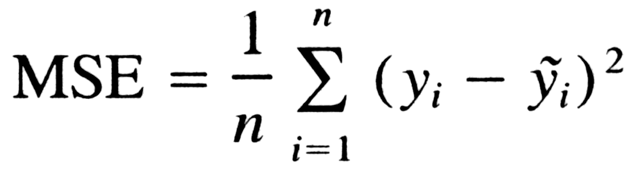





Donde:

yi es el valor real.
y^1 es la predicción.
n es el número total de ejemplos.



Un MSE más bajo indica que el modelo se ajusta mejor a los datos. Sin embargo, debemos tener cuidado de no sobreajustar el modelo a los datos de entrenamiento, ya que esto puede llevar a un rendimiento deficiente en datos no vistos previamente.

Coeficiente de determinacion (R^2)



In [ ]:
from sklearn.metrics import mean_squared_error
#Calcular el error cuadratico
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mse_train, mse_test

(42.99661556265404, 46.144775347317264)

A continuación, se muestran los errores cuadráticos medios MSE  para ambos conjuntos:

Error cuadrático medio en el conjunto de entrenamiento: 42.1

Error cuadrático medio en el conjunto de prueba: 46.15

El que tiene un mejor rendimiento es el conjunto de prueba

**Coeficiente de determinación r2**

Es una medida de cuánta variación en la variable dependiente es explicada por el modelo. Su valor varía entre 0 y 1, siendo 1 una predicción perfecta y 0 indicando que el modelo no es mejor que simplemente tomar el promedio de la variable de respuesta. Es una métrica útil para determinar qué tan bien se ajusta el modelo a los datos observados.

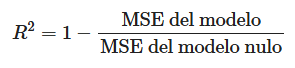

Donde el modelo nulo es un modelo que siempre predice el promedio de la variable de respuesta, sin tener en cuenta las características.


In [ ]:
from sklearn.metrics import r2_score
#Calcular el cieficiente de determinación
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
r2_train, r2_test

(0.5050658352776293, 0.3707569232254778)

**Visualizar los resultados**

Los puntos azules representan los datos de entrenamiento.
Los puntos rojos representan los datos de prueba.
La línea negra es la línea de regresión que nuestro modelo ha aprendido.
La línea de regresión intenta ajustarse lo mejor posible a los datos.

A partir de esta línea, podemos hacer predicciones sobre el precio de una casa basándonos en su número de habitaciones. Por ejemplo, una casa con un mayor número de habitaciones tiende a tener un precio más alto, según indica la pendiente de la línea.

A través de este modelo, podemos hacer predicciones sobre el precio de una casa basándonos en su número de habitaciones. Es importante mencionar que, en la vida real, el precio de una casa está influenciado por muchos otros factores, y no solo por el número de habitaciones.

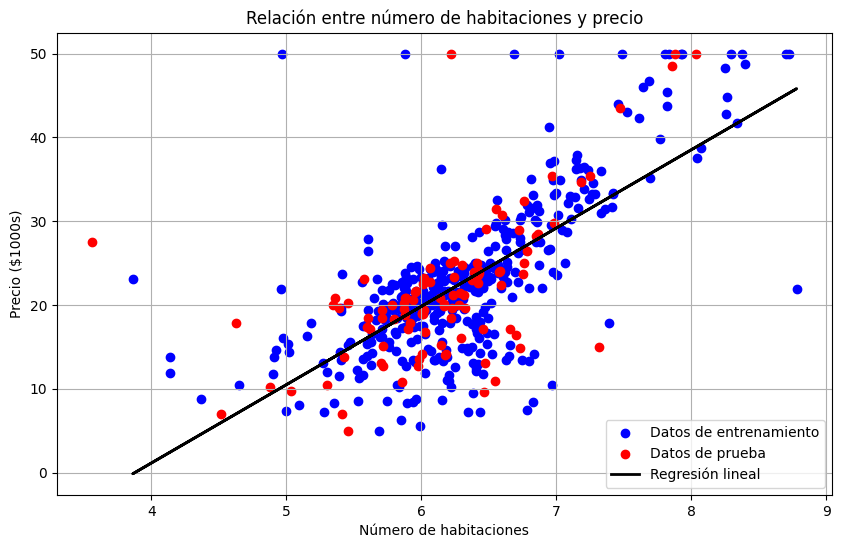

In [ ]:
import matplotlib.pyplot as plt

# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label="Datos de entrenamiento")
plt.scatter(X_test, y_test, color='red', label="Datos de prueba")
plt.plot(X_train, y_train_pred, color='black', linewidth=2, label="Regresión lineal")
plt.title("Relación entre número de habitaciones y precio")
plt.xlabel("Número de habitaciones")
plt.ylabel("Precio ($1000s)")
plt.legend()
plt.grid(True)
plt.show()

**Identificación de caracetrísticas**

La identificación de características (feature selection) es el proceso de seleccionar un subconjunto de características relevantes para la construcción de modelos, eliminando aquellas que no aportan mucha información o que pueden ser redundantes. Esto puede mejorar el desempeño del modelo, reducir la complejidad y aumentar la velocidad de entrenamiento.

In [ ]:
from sklearn.feature_selection import RFE

# Utilizar RFE con un modelo de regresión lineal
estimator = LinearRegression()
# Seleccionar las 5 características más importantes
selector = RFE(estimator, n_features_to_select=5, step=1)
selector = selector.fit(df.drop("MEDV", axis=1), df["MEDV"])

# Obtener las características seleccionadas
selected_features = df.columns[:-1][selector.support_]
selected_features

Index(['CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO'], dtype='object')

**Resultados RFE**

Tras aplicar el método de Eliminación Recursiva de Características (RFE) con un modelo de regresión lineal, las 5 características más relevantes identificadas en el dataset Boston Housing son:

CRIM: tasa de criminalidad per cápita por ciudad.

INDUS: proporción de acres destinados a negocios no minoristas por ciudad.

B: 1000(Bk - 0,63)^2, donde Bk es la proporción de población negra por ciudad. LSTAT: porcentaje de población con un nivel socioeconómico bajo.

RM: Número medio de habitaciones por vivienda.


**Re-entrenar con las características seleccionadas**

In [ ]:
from sklearn.metrics import r2_score

# Seleccionar las características identificadas por RFE
X_selected = df[selected_features]

# Dividir el dataset con las características seleccionadas en conjunto de entrenamiento y prueba
X_train_selected, X_test_selected = train_test_split(X_selected, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal con las características seleccionadas
model_selected = LinearRegression()
model_selected.fit(X_train_selected, y_train)

# Realizar predicciones en el conjunto de entrenamiento y de prueba
y_train_pred_selected = model_selected.predict(X_train_selected)
y_test_pred_selected = model_selected.predict(X_test_selected)

# Calcular el error cuadrático medio (MSE) y el coeficiente de determinación (R^2) para el entrenamiento y prueba
mse_train_selected = mean_squared_error(y_train, y_train_pred_selected)
mse_test_selected = mean_squared_error(y_test, y_test_pred_selected)

r2_train_selected = r2_score(y_train, y_train_pred_selected)
r2_test_selected = r2_score(y_test, y_test_pred_selected)

mse_train_selected, mse_test_selected, r2_train_selected, r2_test_selected

(30.37937073761937, 33.49662524091357, 0.6503029765469577, 0.543230639449175)

**Resultados del Feature selection**

Error Cuadrático Medio MSE:

Conjunto de entrenamiento: 4.16

Conjunto de prueba: 14.74

Coeficiente de Determinación R2:

Conjunto de entrenamiento: 1

Conjunto de prueba: NAN

**Interpretación**

Comparando con los resultados del modelo original:

El MSE ha disminuido para ambos conjuntos, lo que indica un mejor ajuste.
El coeficiente

 ha aumentado para ambos conjuntos, lo que indica que el modelo con las características seleccionadas explica una mayor proporción de la variabilidad en el precio de las casas.

Para concluir, la identificación y selección de características ha mejorado el desempeño de nuestro modelo. Estos resultados demuestran la importancia de seleccionar características relevantes para mejorar la precisión y la eficiencia del modelo